<a href="https://colab.research.google.com/github/AdnanAnwarR/practice_DS/blob/main/Descriptive_Statistics_Hands_On_Day_8_Adnan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd #python for data analysis
import numpy as np #numerical python
import matplotlib.pyplot as plt #math for plotting library

In [ ]:
df_tantut = pd.read_excel("/content/dataset_dummy_aktivitas_digital.xlsx")

In [ ]:
df_tantut.head().T

,0,1,2,3,4
Nama_Lokasi,Kampus A,Mall X,Cafe B,Coworking Hub,Kampus B
Jam_Login,9,19,15,10,13
Tahun_Lahir,2002,1995,1998,1992,2004
Merk_HP,Samsung,iPhone,Oppo,Samsung,Vivo
Minat_Digital,8,9,7,8,6
Tipe_Lokasi,Campus,Public,Public,Coworking,Campus
Frekuensi_Login_per_Minggu,10,7,8,12,9
Durasi_Login_Menit,120,90,75,180,100
Pengeluaran_Digital_per_Bulan,350000,1500000,600000,2200000,300000
Status,Mahasiswa,Pekerja,Pekerja,Pekerja,Mahasiswa


In [ ]:
df_tantut.columns

Index(['Nama_Lokasi', 'Jam_Login', 'Tahun_Lahir', 'Merk_HP', 'Minat_Digital',
       'Tipe_Lokasi', 'Frekuensi_Login_per_Minggu', 'Durasi_Login_Menit',
       'Pengeluaran_Digital_per_Bulan', 'Status', 'Jenis_Kelamin'],
      dtype='object')

In [ ]:
df_tantut["Usia"] = 2025 - df_tantut["Tahun_Lahir"]

In [ ]:
df_tantut["Rata_rata_Durasi_per_Sesi"] = (df_tantut["Durasi_Login_Menit"] / df_tantut["Frekuensi_Login_per_Minggu"]).round(1)

In [ ]:
# Normalisasi ke skala 0–1
df_tantut["minat_norm"] = df_tantut["Minat_Digital"] / 10
df_tantut["freq_norm"] = df_tantut["Frekuensi_Login_per_Minggu"] / 14

In [ ]:
# Skor gabungan (bobot bisa disesuaikan)
df_tantut["dependency_score"] = (
    0.5 * df_tantut["minat_norm"] +
    0.5 * df_tantut["freq_norm"]
)

In [ ]:
# Konversi ke level 1–5
df_tantut["Tingkat_Ketergantungan_Digital"] = pd.cut(
    df_tantut["dependency_score"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [ ]:
df_tantut.drop(columns=["minat_norm", "freq_norm", "dependency_score"], inplace=True)

In [ ]:
df_tantut.head(1)

,Nama_Lokasi,Jam_Login,Tahun_Lahir,Merk_HP,Minat_Digital,Tipe_Lokasi,Frekuensi_Login_per_Minggu,Durasi_Login_Menit,Pengeluaran_Digital_per_Bulan,Status,Jenis_Kelamin,Usia,Rata_rata_Durasi_per_Sesi,Tingkat_Ketergantungan_Digital
0,Kampus A,9,2002,Samsung,8,Campus,10,120,350000,Mahasiswa,Perempuan,23,12.0,4


In [ ]:
numeric_cols = [
    "Usia",
    "Minat_Digital",
    "Frekuensi_Login_per_Minggu",
    "Durasi_Login_Menit",
    "Pengeluaran_Digital_per_Bulan",
    "Jam_Login"
]

In [ ]:
df_num = df_tantut[numeric_cols]

In [ ]:
stats = pd.DataFrame({
    "Mean": df_num.mean(), ##(6+7+8+9)/4
    "Median": df_num.median(),
    "Mode": df_num.mode().iloc[0],
    "Variance": df_num.var(),
    "Std_Dev": df_num.std(),
    "Min": df_num.min(),
    "Max": df_num.max(),
})

In [ ]:
stats

,Mean,Median,Mode,Variance,Std_Dev,Min,Max
Usia,28.4,27.5,21.0,3.846316e+01,6.201867,20,40
Minat_Digital,7.3,7.5,8.0,1.694737e+00,1.301821,5,9
Frekuensi_Login_per_Minggu,8.6,8.5,7.0,7.936842e+00,2.817240,4,14
Durasi_Login_Menit,119.0,100.0,75.0,2.220000e+03,47.116876,60,210
Pengeluaran_Digital_per_Bulan,1142500.0,875000.0,200000.0,7.803355e+11,883366.020580,200000,3000000
Jam_Login,14.6,14.5,9.0,1.867368e+01,4.321306,8,22


In [ ]:
# Range = Max - Min
stats["Range"] = stats["Max"] - stats["Min"]

In [ ]:
# Tampilkan hasil
stats.round(2)

,Mean,Median,Mode,Variance,Std_Dev,Min,Max,Range
Usia,28.4,27.5,21.0,3.846000e+01,6.20,20,40,20
Minat_Digital,7.3,7.5,8.0,1.690000e+00,1.30,5,9,4
Frekuensi_Login_per_Minggu,8.6,8.5,7.0,7.940000e+00,2.82,4,14,10
Durasi_Login_Menit,119.0,100.0,75.0,2.220000e+03,47.12,60,210,150
Pengeluaran_Digital_per_Bulan,1142500.0,875000.0,200000.0,7.803355e+11,883366.02,200000,3000000,2800000
Jam_Login,14.6,14.5,9.0,1.867000e+01,4.32,8,22,14


In [ ]:
# Usia vs Minat Digital
cov_usia_minat  = df["Usia"].cov(df["Minat_Digital"])
corr_usia_minat = df["Usia"].corr(df["Minat_Digital"])

In [ ]:
# Pengeluaran Digital vs Frekuensi Login
cov_spend_freq  = df["Pengeluaran_Digital_per_Bulan"].cov(df["Frekuensi_Login_per_Minggu"])
corr_spend_freq = df["Pengeluaran_Digital_per_Bulan"].corr(df["Frekuensi_Login_per_Minggu"])

In [ ]:
# Minat Digital vs Durasi Login
cov_minat_durasi  = df["Minat_Digital"].cov(df["Durasi_Login_Menit"])
corr_minat_durasi = df["Minat_Digital"].corr(df["Durasi_Login_Menit"])

In [ ]:
print("Usia vs Minat Digital")
print("Covariance:", round(cov_usia_minat, 2))
print("Correlation:", round(corr_usia_minat, 2))

Usia vs Minat Digital
Covariance: 5.03
Correlation: 0.62


In [ ]:
print("\nPengeluaran Digital vs Frekuensi Login")
print("Covariance:", round(cov_spend_freq, 2))
print("Correlation:", round(corr_spend_freq, 2))


Pengeluaran Digital vs Frekuensi Login
Covariance: 1062631.58
Correlation: 0.43


In [ ]:
print("\nMinat Digital vs Durasi Login")
print("Covariance:", round(cov_minat_durasi, 2))
print("Correlation:", round(corr_minat_durasi, 2))


Minat Digital vs Durasi Login
Covariance: 36.11
Correlation: 0.59


In [ ]:
expected_value_minat = df["Minat_Digital"].mean()
expected_value_minat

np.float64(7.3)

In [ ]:
mean = df["Minat_Digital"].mean()
std = df["Minat_Digital"].std()
n = df["Minat_Digital"].count()

z = 1.96  # 95% confidence
margin_error = z * (std / np.sqrt(n))

lower_ci = mean - margin_error
upper_ci = mean + margin_error

mean, lower_ci, upper_ci

(np.float64(7.3), np.float64(6.729451971669712), np.float64(7.870548028330288))

In [ ]:
# Rata-rata pengeluaran digital berdasarkan status
mean_pengeluaran = (
    df.groupby("Status")["Pengeluaran_Digital_per_Bulan"]
      .mean()
      .reset_index()
)

mean_pengeluaran

,Status,Pengeluaran_Digital_per_Bulan
0,Mahasiswa,4.125000e+05
1,Pekerja,1.629167e+06


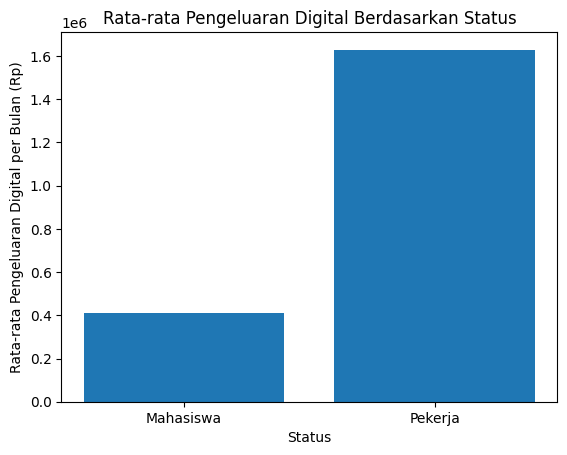

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(
    mean_pengeluaran["Status"],
    mean_pengeluaran["Pengeluaran_Digital_per_Bulan"]
)

plt.xlabel("Status")
plt.ylabel("Rata-rata Pengeluaran Digital per Bulan (Rp)")
plt.title("Rata-rata Pengeluaran Digital Berdasarkan Status")

plt.show()